In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$ 

In [44]:
import numpy as np 
import matplotlib.pyplot as plt 

In [45]:
# We first define the constants
p_1 = 1/np.sqrt(2)
p_2 = 0
p_3 = 0.7
N = 200
iteration_count = 1000
number_deltas = 10
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.
We pick the function $g(x,y) = x+y$

In [46]:
# step transition probabilities
def take_step(x, y, p):
    generated_prob = np.random.random()

    if generated_prob > p:
        return (x+1) % N, y 
    else:
        return x, (y+1) % N

def g(x, y):
    return_list = []
    for i in range(len(x)):
        return_list.append(np.cos(2*np.pi*(x[i]+y[i])/N))
    return return_list

# compute delta
def g_mean(x_list, y_list, g=g):
    return np.absolute(np.mean(g(x_list, y_list)))

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}f(X_i) - \mathbb{E}[f(X)] |
\end{equation}

We know from 3.17 page 22 of the paper that for a rational p, we have that the supremum function is
\begin{equation}
f(x) = e^{\frac{2\pi i}{N}\sum\limits_{j=1}^{d}m_jx_j}
\end{equation}
with the constraint that $m_1, \dots, m_d$ are not all zero and verify the property 
\begin{equation}
\sum\limits_{j=1}^{d}m_j(p_j-p_{-j}).
\end{equation}

In our case we have $m_1 \cdot p + m_2 \cdot(1-p) = 0$, and setting $p=0.7$ we obtain $0.7m_1 + 0.3m_2 = 0$ where we pick $m_1 = 3$ and $m_2 = -7$

\begin{equation}
\Delta_n = \sqrt{\mathbb{E}[\frac{1}{n^2}(\sum\limits_{k=0}^{n-1}cos(\frac{2\pi}{N}(m_1x_k+m_2y_k))^2 + (\sum\limits_{k=0}^{n-1}sin(\frac{2\pi}{N}(m_1x_k+m_2y_k)))^2)]}
\end{equation}

In [ ]:
def compute_delta(p):
    print(p)
    all_deltas = np.zeros((number_deltas, iteration_count))

    for j in range(number_deltas):
        curr_x, curr_y = 0, 0
        g_sum = 0
        for i in range(iteration_count):
            # take a step, then compute g
            curr_x, curr_y = take_step(curr_x, curr_y, p)
            val = np.sin(2*np.pi*(3*curr_x-7*curr_y)/N)

            # compute empirical average of g after drawing i samples
            g_sum += val 
            all_deltas[j, i] = g_sum/(i+1)
    delta_n = np.sqrt(np.mean(all_deltas**2, axis=0))
    return delta_n

In [48]:
delta_n_1 = compute_delta(p_1)
delta_n_2 = compute_delta(p_2)
delta_n_3 = compute_delta(p_3)

0.7071067811865475
0
0.7


Now we plot $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

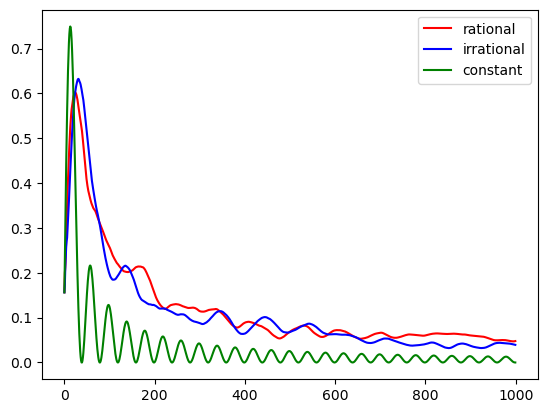

In [49]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="rational")
plt.plot(range(iteration_count), delta_n_3, c="b", label="irrational")
plt.plot(range(iteration_count), delta_n_2, c="g", label="constant")
#plt.plot(range(iteration_count), [np.sqrt(0.2 * N**(4/3)/n) for n in range(1, iteration_count+1)], c="b", label="relaxation time")
plt.legend()